In [3]:
%load_ext autoreload
%autoreload 2
import os
import sys
import torch
import json
from time import time, perf_counter
from openai import OpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from config import Config
from agents.hyde_retriever import HyDERetriever


/home/jandy/miniconda3/envs/ragnarok/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
TEST_CASES = [
    # === CLEAN RETRIEVAL — SPEAR baseline already works ===
    {
        "query_id": 1,
        "query": "I am currently invisible and want to shoot my bow at the guard. Do I get advantage?",
        "ground_truth_keywords": ["unseen", "advantage", "attack roll", "can't see"],
        "correct_mechanic": "Unseen attacker has advantage on attack rolls; invisible condition grants advantage on attack rolls",
        "expected_rank": 2,
        "difficulty": "easy"
    },
    {
        "query_id": 2,
        "query": "My fighter wants to grab the cultist and wrestle him to the ground. How does that work?",
        "ground_truth_keywords": ["grapple", "athletics", "acrobatics", "contested", "grappled"],
        "correct_mechanic": "Strength (Athletics) contested by Athletics or Acrobatics, applies grappled condition",
        "expected_rank": 3,
        "difficulty": "easy"
    },
    {
        "query_id": 4,
        "query": "What happens to my character if I drop to exactly 0 hit points?",
        "ground_truth_keywords": ["0 hit points", "unconscious", "death saving throw", "fall"],
        "correct_mechanic": "Fall unconscious, begin death saving throws",
        "expected_rank": 1,
        "difficulty": "easy"
    },
    {
        "query_id": 5,
        "query": "I try to pickpocket Arin's coin purse without him noticing.",
        "ground_truth_keywords": ["sleight of hand", "dexterity", "coin purse", "pocket", "legerdemain"],
        "correct_mechanic": "Dexterity (Sleight of Hand) check, contested by Wisdom (Perception)",
        "expected_rank": 3,
        "difficulty": "easy"
    },
    {
        "query_id": 6,
        "query": "I attempt to shove the bandit captain backwards into the fireplace.",
        "ground_truth_keywords": ["shove", "athletics", "acrobatics", "contested", "prone", "push"],
        "correct_mechanic": "Strength (Athletics) contested by Athletics or Acrobatics, push 5 feet or knock prone",
        "expected_rank": 2,
        "difficulty": "easy"
    },
    {
        "query_id": 8,
        "query": "I want to hide behind the bar mid-combat. Do I need to take an action for that?",
        "ground_truth_keywords": ["hide action", "dexterity", "stealth", "action"],
        "correct_mechanic": "Hide is an action, make Dexterity (Stealth) check",
        "expected_rank": 1,
        "difficulty": "easy"
    },
    {
        "query_id": 10,
        "query": "The enemy walks away from me mid-combat. Can I attack them as they leave?",
        "ground_truth_keywords": ["opportunity attack", "reaction", "reach", "melee attack", "disengage"],
        "correct_mechanic": "Opportunity attack — reaction, one melee attack when hostile leaves reach",
        "expected_rank": 1,
        "difficulty": "easy"
    },
    {
        "query_id": 11,
        "query": "I fell off the chandelier, about 30 feet up. How much damage do I take?",
        "ground_truth_keywords": ["falling", "1d6", "bludgeoning", "10 feet", "prone"],
        "correct_mechanic": "1d6 bludgeoning per 10 feet fallen, max 20d6, land prone",
        "expected_rank": 3,
        "difficulty": "easy"
    },
    {
        "query_id": 13,
        "query": "I want to help my ally hit the bandit. Can I do something to give them a better chance?",
        "ground_truth_keywords": ["help action", "advantage", "attack roll", "aid", "ally"],
        "correct_mechanic": "Help action — ally gains advantage on next attack roll against creature within 5 feet",
        "expected_rank": 1,
        "difficulty": "easy"
    },
    {
        "query_id": 14,
        "query": "I'm going to dodge this turn instead of attacking. What exactly does that give me?",
        "ground_truth_keywords": ["dodge action", "disadvantage", "attack roll", "dexterity saving throw", "advantage"],
        "correct_mechanic": "Attack rolls against you have disadvantage, Dex saves with advantage until next turn",
        "expected_rank": 2,
        "difficulty": "easy"
    },
    {
        "query_id": 19,
        "query": "I successfully grappled the bandit. Can I drag him across the tavern now?",
        "ground_truth_keywords": ["drag", "grappled", "speed", "halved", "carry"],
        "correct_mechanic": "Can drag grappled creature, speed halved unless creature is two or more sizes smaller",
        "expected_rank": 1,
        "difficulty": "easy"
    },
    {
        "query_id": 20,
        "query": "My character just rolled their third failed death saving throw. What happens?",
        "ground_truth_keywords": ["third", "failure", "die", "death saving throw", "three"],
        "correct_mechanic": "On third failure, character dies",
        "expected_rank": 1,
        "difficulty": "easy"
    },

    # === RETRIEVAL FAILURES — where HyDE should show improvement ===
    {
        "query_id": 3,
        "query": "I want to cast Magic Missile. Does it require an attack roll?",
        "ground_truth_keywords": ["magic missile", "attack roll", "automatically", "force damage", "dart"],
        "correct_mechanic": "Magic Missile requires no attack roll — it hits automatically",
        "expected_rank": None,  # not found in top 10
        "difficulty": "hard"
    },
    {
        "query_id": 7,
        "query": "I'm concentrating on Bless and I want to cast Invisibility on myself. Can I do both?",
        "ground_truth_keywords": ["concentration", "one", "spell", "end", "casting another"],
        "correct_mechanic": "Can only concentrate on one spell at a time — casting Invisibility ends Bless",
        "expected_rank": None,  # not found in top 10
        "difficulty": "hard"
    },
    {
        "query_id": 9,
        "query": "I try to run away from the enemy but I don't want to get hit on the way out. What do I do?",
        "ground_truth_keywords": ["disengage", "action", "opportunity attack", "movement", "provoke"],
        "correct_mechanic": "Disengage action — movement doesn't provoke opportunity attacks for the rest of the turn",
        "expected_rank": 6,  # buried inside OA section
        "difficulty": "medium"
    },
    {
        "query_id": 12,
        "query": "I want to ready my crossbow and shoot the first person who walks through the door.",
        "ground_truth_keywords": ["ready", "action", "trigger", "reaction", "perceivable circumstance"],
        "correct_mechanic": "Ready action — choose trigger and reaction, use reaction when trigger occurs",
        "expected_rank": None,  # not found in top 10
        "difficulty": "hard"
    },
    {
        "query_id": 15,
        "query": "The enemy knocked me prone. How do I stand back up and can I still attack this turn?",
        "ground_truth_keywords": ["prone", "stand up", "half", "speed", "movement", "disadvantage attack"],
        "correct_mechanic": "Standing up costs half speed, prone gives disadvantage on attack rolls",
        "expected_rank": 6,  # buried
        "difficulty": "medium"
    },
    {
        "query_id": 16,
        "query": "I want to attack with my sword and also cast Fireball in the same turn. Can I?",
        "ground_truth_keywords": ["action", "cast a spell", "attack action", "bonus action", "cantrip"],
        "correct_mechanic": "Attack action and casting a leveled spell both use your action — cannot do both without Action Surge",
        "expected_rank": None,  # not found in top 10
        "difficulty": "hard"
    },
    {
        "query_id": 17,
        "query": "I want to wield a shortsword in each hand and attack with both. How does that work?",
        "ground_truth_keywords": ["two-weapon fighting", "light", "bonus action", "off-hand", "ability modifier"],
        "correct_mechanic": "Both weapons must have Light property, off-hand attack is a bonus action, no ability modifier to damage",
        "expected_rank": 5,  # partial — style retrieved but not core rule
        "difficulty": "medium"
    },
    {
        "query_id": 18,
        "query": "My barbarian wants to swing wildly to guarantee a hit. Is there a way to do that?",
        "ground_truth_keywords": ["reckless attack", "advantage", "melee weapon", "strength", "attack rolls against you"],
        "correct_mechanic": "Reckless Attack — advantage on melee Strength attacks, but attack rolls against you also have advantage",
        "expected_rank": 5,  # buried
        "difficulty": "medium"
    },
]

In [20]:
def check_hit(chunks: list, keywords: list, threshold: float = 0.6) -> bool:
    """
    Checks if any single chunk contains enough of the required keywords.
    Threshold: Percentage of keywords that must be present (default 60%).
    """
    for chunk in chunks:
        chunk_lower = chunk.lower()
        matches = sum(1 for kw in keywords if kw.lower() in chunk_lower)
        if matches / len(keywords) >= threshold:
            return True
    return False

def run_evaluation(hyde_model):
    # 1. Hardware Check
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[*] Running Evaluation on: {device.upper()}\n")

    # 2. Initialize Client
    client = OpenAI(base_url=Config.OLLAMA_BASE_URL, api_key="ollama")

    # 3. Initialize Standard SPEAR (Raw Vector Store)
    print("[*] Initializing Standard SPEAR Retriever...")
    embeddings = HuggingFaceEmbeddings(
        model_name=Config.EMBEDDING_MODEL,
        model_kwargs={'device': device}
    )
    standard_vs = Chroma(
        persist_directory=str(Config.DATA_DIR / "chroma_db"),
        embedding_function=embeddings
    )

    # 4. Initialize SPEAR+HyDE
    print(f"[*] Initializing SPEAR+HyDE Retriever (Model: {hyde_model})...")
    hyde_rules = HyDERetriever(client, model_profile="LOCAL", mode="rules", hyde_model=hyde_model)

    print("\n" + "="*70)
    print("STARTING HEAD-TO-HEAD RETRIEVAL EVALUATION (ACCURACY & LATENCY)")
    print("="*70)

    results = {
        "easy": {"spear": 0, "hyde": 0, "total": 0},
        "medium": {"spear": 0, "hyde": 0, "total": 0},
        "hard": {"spear": 0, "hyde": 0, "total": 0},
        "total": {"spear": 0, "hyde": 0, "tokens": 0, "spear_time": 0.0, "hyde_time": 0.0}
    }

    for i, case in enumerate(TEST_CASES, 1):
        diff = case["difficulty"]
        results[diff]["total"] += 1
        
        print(f"\n[Test {i}/{len(TEST_CASES)} | {diff.upper()}] Query: '{case['query'][:50]}...'")
        
        # --- Run Standard SPEAR (Timed) ---
        t0_spear = perf_counter()
        standard_docs = standard_vs.similarity_search(case['query'], k=5)
        t1_spear = perf_counter()
        
        spear_lat = (t1_spear - t0_spear) * 1000  # Convert to ms
        results["total"]["spear_time"] += spear_lat
        standard_chunks = [doc.page_content for doc in standard_docs]
        spear_hit = check_hit(standard_chunks, case["ground_truth_keywords"])
        
        # --- Run SPEAR+HyDE (Timed) ---
        t0_hyde = perf_counter()
        hyde_docs, tokens = hyde_rules.retrieve(case['query'], world_context="")
        t1_hyde = perf_counter()
        
        hyde_lat = (t1_hyde - t0_hyde) * 1000  # Convert to ms
        results["total"]["hyde_time"] += hyde_lat
        results["total"]["tokens"] += tokens
        
        hyde_chunks = [getattr(doc, "page_content", "") for doc in hyde_docs]
        hyde_hit = check_hit(hyde_chunks, case["ground_truth_keywords"])
        
        # --- Tally Results ---
        if spear_hit: results[diff]["spear"] += 1
        if hyde_hit: results[diff]["hyde"] += 1
        if spear_hit: results["total"]["spear"] += 1
        if hyde_hit: results["total"]["hyde"] += 1

        # --- Print Turn Summary ---
        spear_mark = "✅" if spear_hit else "❌"
        hyde_mark = "✅" if hyde_hit else "❌"
        
        print(f"  Standard SPEAR : {spear_mark} ({spear_lat:.1f} ms)")
        print(f"  SPEAR+HyDE     : {hyde_mark} ({hyde_lat:.1f} ms | Cost: {tokens} tokens)")

    # 6. Final Report
    print("\n" + "="*70)
    print(f"FINAL EVALUATION RESULTS WITH HyDE MODEL {hyde_model} (Hit Rate @ 5)")
    print("="*70)
    print(f"Total Queries Tested: {len(TEST_CASES)}\n")
    
    for diff in ["easy", "medium", "hard"]:
        total = results[diff]["total"]
        if total == 0: continue
        s_rate = (results[diff]["spear"] / total) * 100
        h_rate = (results[diff]["hyde"] / total) * 100
        print(f"Difficulty: {diff.upper()} (N={total})")
        print(f"  SPEAR:      {results[diff]['spear']}/{total} ({s_rate:.1f}%)")
        print(f"  SPEAR+HyDE: {results[diff]['hyde']}/{total} ({h_rate:.1f}%)\n")

    s_total_rate = (results["total"]["spear"] / len(TEST_CASES)) * 100
    h_total_rate = (results["total"]["hyde"] / len(TEST_CASES)) * 100
    
    avg_spear_lat = results["total"]["spear_time"] / len(TEST_CASES)
    avg_hyde_lat = results["total"]["hyde_time"] / len(TEST_CASES)
    
    print("-" * 70)
    print(f"OVERALL SPEAR Hit Rate      : {results['total']['spear']}/{len(TEST_CASES)} ({s_total_rate:.1f}%)")
    print(f"OVERALL SPEAR+HyDE Hit Rate : {results['total']['hyde']}/{len(TEST_CASES)} ({h_total_rate:.1f}%)")
    print("-" * 70)
    print(f"Average SPEAR Latency       : {avg_spear_lat:.1f} ms")
    print(f"Average SPEAR+HyDE Latency  : {avg_hyde_lat:.1f} ms")
    print(f"Total HyDE Token Overhead   : {results['total']['tokens']} tokens")
    print("="*70)

In [21]:
run_evaluation("qwen2.5:7b")

[*] Running Evaluation on: CUDA

[*] Initializing Standard SPEAR Retriever...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2763.45it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Initializing SPEAR+HyDE Retriever (Model: qwen2.5:7b)...
[HyDERetriever] Initialized in 'rules' mode.

STARTING HEAD-TO-HEAD RETRIEVAL EVALUATION (ACCURACY & LATENCY)

[Test 1/20 | EASY] Query: 'I am currently invisible and want to shoot my bow ...'
[HyDE:rules] Starting retrieval for: 'I am currently invisible and want to shoot my bow at the gua'
[HyDE:rules] Generating 3 hypothetical documents in parallel...
[HyDE:rules] Hypothesis 1: 265 tokens | 'This action does not require an ability check or saving throw. It succeeds automatically. However, you have advantage on attack rolls against the guard because you are invisible.'
[HyDE:rules] Hypothesis 2: 277 tokens | 'This action does not require an ability check or saving throw. It succeeds automatically. However, you must use your action to make the attack roll, and you have advantage on the attack roll because you are invisible.'
[HyDE:rules] Hypothesis 3: 309 tokens | 'This action does not require an ability check or saving thro

In [22]:
run_evaluation("phi3.5:3.8b")

[*] Running Evaluation on: CUDA

[*] Initializing Standard SPEAR Retriever...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2727.62it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Initializing SPEAR+HyDE Retriever (Model: phi3.5:3.8b)...
[HyDERetriever] Initialized in 'rules' mode.

STARTING HEAD-TO-HEAD RETRIEVAL EVALUATION (ACCURACY & LATENCY)

[Test 1/20 | EASY] Query: 'I am currently invisible and want to shoot my bow ...'
[HyDE:rules] Starting retrieval for: 'I am currently invisible and want to shoot my bow at the gua'
[HyDE:rules] Generating 3 hypothetical documents in parallel...
[HyDE:rules] Hypothesis 1: 530 tokens | '**Invisibility and Ranged Attack:**

When attempting a ranged attack as an invisible creature, you may choose to make a Dexterity (Ranged Spell) attack roll. If you are unseen due to your invisibility, you may declare that you have advantage on this attack roll. If you do, roll both dice for the attack. If the total of your rolls is equal to or greater than the ranged attack roll (DC) of the target, the attack is successful. Note that being invisible does not grant you advantage on the attack roll itself; it only affects the outcome i

In [23]:
run_evaluation("llama3.2")

[*] Running Evaluation on: CUDA

[*] Initializing Standard SPEAR Retriever...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2701.35it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Initializing SPEAR+HyDE Retriever (Model: llama3.2)...
[HyDERetriever] Initialized in 'rules' mode.

STARTING HEAD-TO-HEAD RETRIEVAL EVALUATION (ACCURACY & LATENCY)

[Test 1/20 | EASY] Query: 'I am currently invisible and want to shoot my bow ...'
[HyDE:rules] Starting retrieval for: 'I am currently invisible and want to shoot my bow at the gua'
[HyDE:rules] Generating 3 hypothetical documents in parallel...
[HyDE:rules] Hypothesis 1: 260 tokens | 'Stealth Check. When you hide, you can make a Stealth check to remain hidden. If the check equals or exceeds the DC, you remain hidden.'
[HyDE:rules] Hypothesis 2: 237 tokens | 'Stealth (Invisibility)'
[HyDE:rules] Hypothesis 3: 237 tokens | 'Stealth Check'
[HyDE:rules] Hypothesis generation complete: 734 tokens total | 5670ms
[HyDE:rules] Vector search: 15 docs from hypotheses + 2 from direct | 17 unique | 39ms
[HyDE:rules] Final: 5 docs returned to orchestrator | 734 total tokens
  Standard SPEAR : ✅ (21.2 ms)
  SPEAR+HyDE     : ❌ (5710

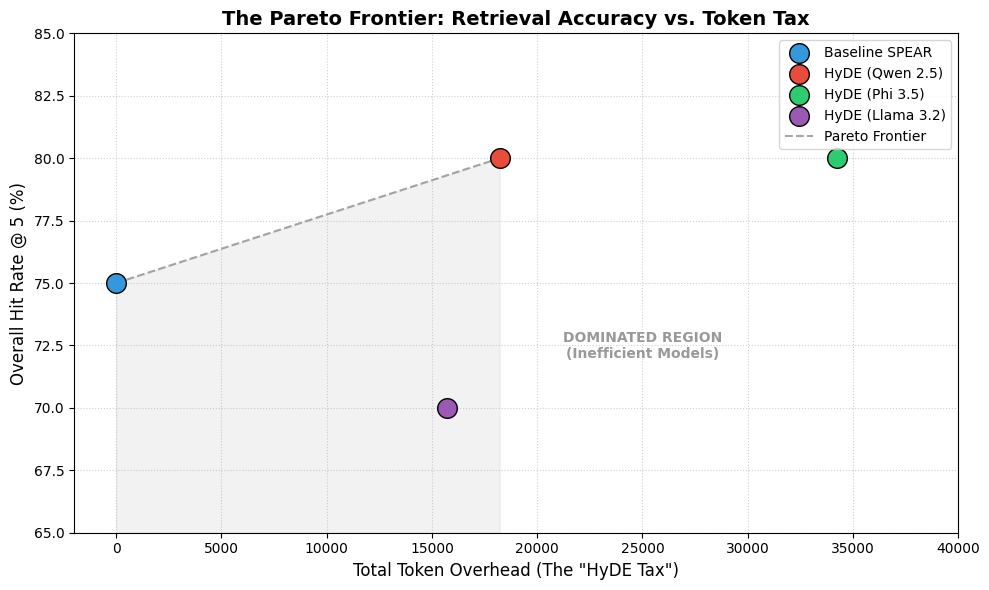

In [ ]:
# Data from final 20-query evaluation runs
data = {
    'Model': ['Baseline SPEAR', 'HyDE (Qwen 2.5)', 'HyDE (Phi 3.5)', 'HyDE (Llama 3.2)'],
    'Hit_Rate': [75.0, 80.0, 80.0, 70.0],
    'Token_Cost': [0, 18215, 34225, 15733],
    'Color': ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
}

df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))

# Plot the points
for i in range(len(df)):
    plt.scatter(df.Token_Cost[i], df.Hit_Rate[i], color=df.Color[i], s=200, label=df.Model[i], edgecolors='black', zorder=3)

# Draw the Pareto Frontier line (Baseline -> Qwen 2.5)
# Note: Phi and Llama are "Dominated" and don't make the line
frontier_x = [0, 18215]
frontier_y = [75, 80]
plt.plot(frontier_x, frontier_y, linestyle='--', color='gray', alpha=0.7, label='Pareto Frontier', zorder=1)

# Annotations
plt.title('The Pareto Frontier: Retrieval Accuracy vs. Token Tax', fontsize=14, fontweight='bold')
plt.xlabel('Total Token Overhead (The "HyDE Tax")', fontsize=12)
plt.ylabel('Overall Hit Rate @ 5 (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(65, 85)
plt.xlim(-2000, 40000)
plt.legend()

# Add a "Region of Domination" highlight
plt.fill_between(frontier_x, 65, frontier_y, color='gray', alpha=0.1)
plt.text(25000, 72, "DOMINATED REGION\n(Inefficient Models)", color='gray', alpha=0.8, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

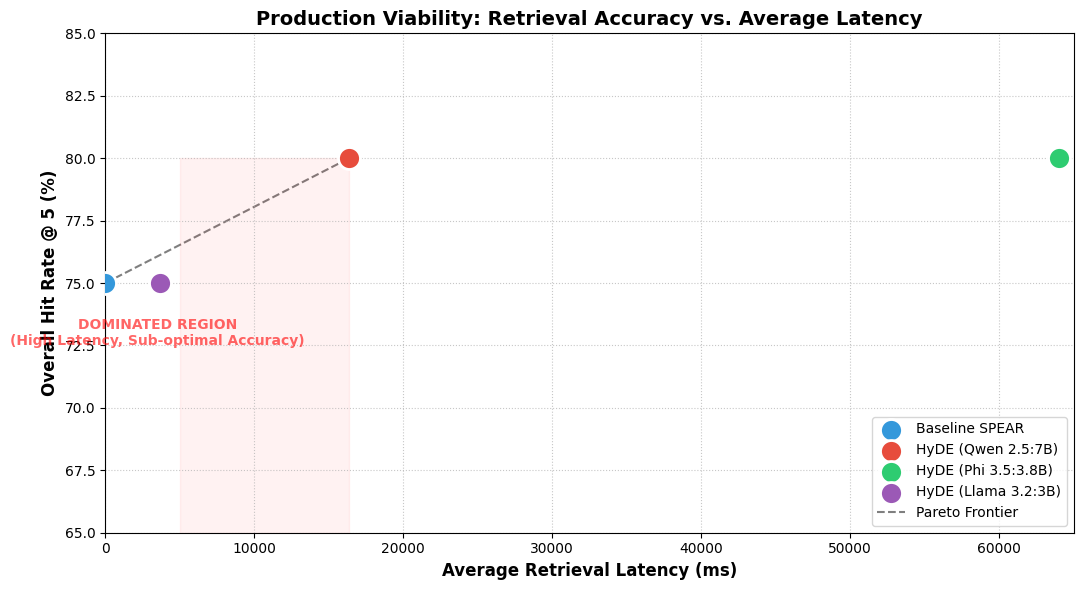

In [4]:
data = {
    'Model': ['Baseline SPEAR', 'HyDE (Qwen 2.5:7B)', 'HyDE (Phi 3.5:3.8B)', 'HyDE (Llama 3.2:3B)'],
    'Hit_Rate': [(75.0+75.0+75.0)/3, 80.0, 80.0, 75.0],
    'Latency_ms': [(11.3+10.1+8.2)/3, 16382.9, 64012.5, 3677.2], # Replace these with your actual average ms
    'Color': ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
}

df = pd.DataFrame(data)

plt.figure(figsize=(11, 6))

# Plot the points
for i in range(len(df)):
    plt.scatter(df.Latency_ms[i], df.Hit_Rate[i], color=df.Color[i], 
                s=250, label=df.Model[i], edgecolors='white', linewidths=2, zorder=3)

# Draw the Pareto Frontier line (Baseline -> Qwen 2.5)
# Assuming Qwen has the best latency-to-accuracy ratio of the HyDE models
frontier_x = [df.Latency_ms[0], df.Latency_ms[1]]
frontier_y = [df.Hit_Rate[0], df.Hit_Rate[1]]
plt.plot(frontier_x, frontier_y, linestyle='--', color='black', alpha=0.5, label='Pareto Frontier', zorder=1)

# Highlight the "Dominated" Region (Too slow, too inaccurate)
plt.fill_between([df.Latency_ms[1], 5000], df.Hit_Rate[1], 65, color='red', alpha=0.05)
plt.text(3500, 72.5, "DOMINATED REGION\n(High Latency, Sub-optimal Accuracy)", 
         color='red', alpha=0.6, ha='center', fontweight='bold')

# Formatting
plt.title('Production Viability: Retrieval Accuracy vs. Average Latency', fontsize=14, fontweight='bold')
plt.xlabel('Average Retrieval Latency (ms)', fontsize=12, fontweight='bold')
plt.ylabel('Overall Hit Rate @ 5 (%)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(65, 85)
plt.xlim(0, max(df.Latency_ms) + 1000)
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig('pareto_latency_accuracy.png', dpi=300)
plt.show()